# Plot Rainfall at Houston Distance

C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


Figure saved at: Plot_Rainfall_80km_Comparison\Rainfall_Cluster_Pairs_at_Houston.png


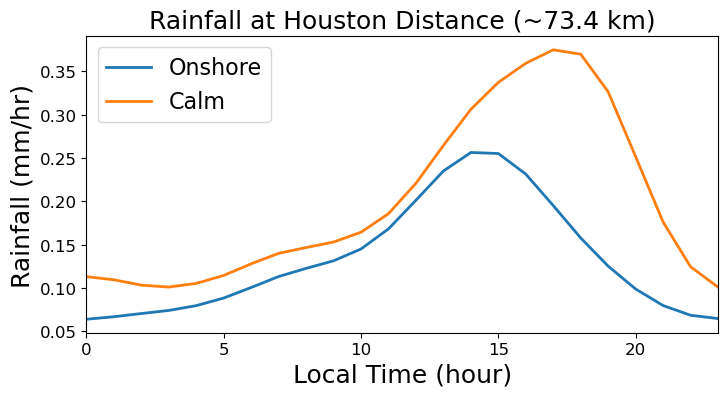

In [1]:
# -*- coding: utf-8 -*-
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon, LineString
from shapely.ops import nearest_points
from geopy.distance import geodesic
from scipy.ndimage import gaussian_filter
from pathlib import Path

# =============================================
# Plot formatting (match earlier style)
# =============================================
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 16,
    'figure.titlesize': 16
})

# =============================================
# Setup
# =============================================
plot_dir = Path("Plot_Rainfall_80km_Comparison")
plot_dir.mkdir(exist_ok=True)

# Define region and line
coastline = gpd.read_file("clipped_us_coastline.shp")
black_box = Polygon([
    (-95.1487, 26.2953), (-92.4741, 27.6542),
    (-94.7388, 32.1118), (-97.4134, 30.7530)
])
middle_line = LineString([(-96.2810, 28.5242), (-93.6064, 29.8830)])

# Houston distance (km) along your signed-distance axis
HOUSTON_KM = 73.4

def calculate_distance(lat, lon):
    point = Point(lon, lat)
    if not black_box.contains(point):
        return np.nan

    # distance to the middle_line
    nearest_point = middle_line.interpolate(middle_line.project(point))
    distance_km = geodesic((lat, lon), (nearest_point.y, nearest_point.x)).km

    # sign (land vs sea side) based on cross-product
    nearest_coast = nearest_points(point, coastline.geometry.unary_union)[1]
    coast_to_line = middle_line.interpolate(middle_line.project(nearest_coast))
    line_vec = np.array([
        middle_line.coords[1][0] - middle_line.coords[0][0],
        middle_line.coords[1][1] - middle_line.coords[0][1]
    ])
    point_vec = np.array([lon - coast_to_line.x, lat - coast_to_line.y])
    cross = np.cross(line_vec, point_vec)

    return distance_km if cross > 0 else -distance_km

# =============================================
# Helper function: Process one cluster file
# =============================================
def process_cluster_file(filename, bin_edges):
    ds = xr.open_dataarray(filename)

    lats = ds.lat.values
    lons = ds.lon.values
    hours = ds.hour.values

    # Pre-compute distance grid once (lat, lon)
    points = [Point(lon, lat) for lat in lats for lon in lons]
    distances = [calculate_distance(pt.y, pt.x) for pt in points]
    distance_grid = np.array(distances).reshape((len(lats), len(lons)))

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    mean_rain = np.full((len(bin_centers), ds.shape[0]), np.nan)

    for t in range(ds.shape[0]):
        rain = ds[t, :, :].values.flatten()
        dist = distance_grid.flatten()

        # bin index per gridpoint
        bin_idx = np.digitize(dist, bin_edges) - 1

        for i in range(len(bin_centers)):
            mask = bin_idx == i
            if np.any(mask):
                mean_rain[i, t] = np.nanmean(rain[mask])

    return mean_rain, bin_centers, hours

# =============================================
# Process and combine cluster pairs
# =============================================
bin_edges = np.arange(-300, 300, 10)

# Pair labels consistent with earlier plots
labels = ["Onshore", "Calm"]
results = {}

# Cluster Pair 0 & 1
rain_0, bin_centers, hours = process_cluster_file(
    "CMORPH_ADJ_8km_daily_1998_2024_LT_lonadj_cluster0_composite.nc", bin_edges
)
rain_1, _, _ = process_cluster_file(
    "CMORPH_ADJ_8km_daily_1998_2024_LT_lonadj_cluster1_composite.nc", bin_edges
)
mean_01 = (rain_0 + rain_1) / 2.0
smoothed_01 = gaussian_filter(mean_01, sigma=1)

idx_houston = np.argmin(np.abs(bin_centers - HOUSTON_KM))
results[labels[0]] = smoothed_01[idx_houston, :]

# Cluster Pair 2 & 3
rain_2, _, _ = process_cluster_file(
    "CMORPH_ADJ_8km_daily_1998_2024_LT_lonadj_cluster2_composite.nc", bin_edges
)
rain_3, _, _ = process_cluster_file(
    "CMORPH_ADJ_8km_daily_1998_2024_LT_lonadj_cluster3_composite.nc", bin_edges
)
mean_23 = (rain_2 + rain_3) / 2.0
smoothed_23 = gaussian_filter(mean_23, sigma=1)
results[labels[1]] = smoothed_23[idx_houston, :]

# =============================================
# Plotting (match earlier formatting)
# =============================================
fig, ax = plt.subplots(1, 1, figsize=(7.5, 4.2))

for label, rainfall in results.items():
    ax.plot(hours, rainfall, linewidth=2, label=label)

ax.set_xlabel("Local Time (hour)")
ax.set_ylabel("Rainfall (mm/hr)")
ax.set_title(f"Rainfall at Houston Distance (~{HOUSTON_KM:.1f} km)")
ax.set_xlim(np.nanmin(hours), np.nanmax(hours))
ax.legend(loc="best")

plt.tight_layout()

# Save plot
outpath = plot_dir / "Rainfall_Cluster_Pairs_at_Houston.png"
plt.savefig(outpath, dpi=300)
#plt.close()
print(f"Figure saved at: {outpath}")

plt.show()
